<a href="https://colab.research.google.com/github/mcklrrn-corpuz/CPE-313/blob/main/Copy_of_CPE313_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **01 |** Imports

In [ ]:
import pandas as pd
import numpy as np

# === Visualization ===
import matplotlib.pyplot as plt

# === Time Series ===
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# === Modelling ===
from statsmodels.tsa.arima.model import ARIMA

# === Ignore warnings ===
import warnings
warnings.filterwarnings('ignore')

# **02 |** Dataset Loading

In [ ]:
# Batch 0
flow0 = pd.read_csv('/content/drive/Shareddrives/Water/discharge(0).csv')
ph0 = pd.read_csv('/content/drive/Shareddrives/Water/ph(0).csv')
cond0 = pd.read_csv('/content/drive/Shareddrives/Water/specific_conductance(0).csv')
temp0 = pd.read_csv('/content/drive/Shareddrives/Water/temp(0).csv')
do0 = pd.read_csv('/content/drive/Shareddrives/Water/dissolved_oxygen(0).csv')

# Batch 1
flow1 = pd.read_csv('/content/drive/Shareddrives/Water/discharge.csv')
ph1 = pd.read_csv('/content/drive/Shareddrives/Water/ph.csv')
cond1 = pd.read_csv('/content/drive/Shareddrives/Water/specific_conductance.csv')
temp1 = pd.read_csv('/content/drive/Shareddrives/Water/temp.csv')
do1 = pd.read_csv('/content/drive/Shareddrives/Water/dissolved_oxygen.csv')

# Batch 2
flow2 = pd.read_csv('/content/drive/Shareddrives/Water/discharge(1).csv')
ph2 = pd.read_csv('/content/drive/Shareddrives/Water/ph(1).csv')
cond2 = pd.read_csv('/content/drive/Shareddrives/Water/specific_conductance(1).csv')
temp2 = pd.read_csv('/content/drive/Shareddrives/Water/temp(1).csv')
do2 = pd.read_csv('/content/drive/Shareddrives/Water/dissolved_oxygen(1).csv')

# **03 |** Preprocessing

In [ ]:
def concat(df1, df2, df3, col_name):
  df = pd.concat([df1, df2, df3])
  df['time'] = pd.to_datetime(df['time'])
  df = df.sort_values(by='time').reset_index(drop=True)
  df = df[['time', 'value']]
  df = df.rename(columns={'value': col_name, 'time': 'datetime'})

  return df

In [ ]:
flow = concat(flow0, flow1, flow2, 'discharge')
ph = concat(ph0, ph1, ph2, 'pH')
cond =  concat(cond0, cond1, cond2, 'conductance')
temp = concat(temp0, temp1, temp2, 'temp')
do = concat(do0, do1, do2, 'do')

In [ ]:
df = flow.merge(ph, on='datetime', how='outer') \
         .merge(cond, on='datetime', how='outer') \
         .merge(temp, on='datetime', how='outer') \
         .merge(do, on='datetime', how='outer')

df = df.sort_values('datetime').set_index('datetime')

In [ ]:
df.shape

(166980, 5)

In [ ]:
df_resampled = df.resample('D').mean()

In [ ]:
df_resampled.shape

(2008, 5)

In [ ]:
df_resampled.isna().sum()

,0
discharge,424
pH,427
conductance,403
temp,430
do,417


In [ ]:
df_filled = df_resampled.copy()

df_filled = df_filled.ffill(limit=3)
df_filled = df_filled.interpolate(method='time')
df_filled = df_filled.bfill()

In [ ]:
df_filled.isna().sum()

,0
discharge,0
pH,0
conductance,0
temp,0
do,0


# **04 |** Exploratory Data Analysis

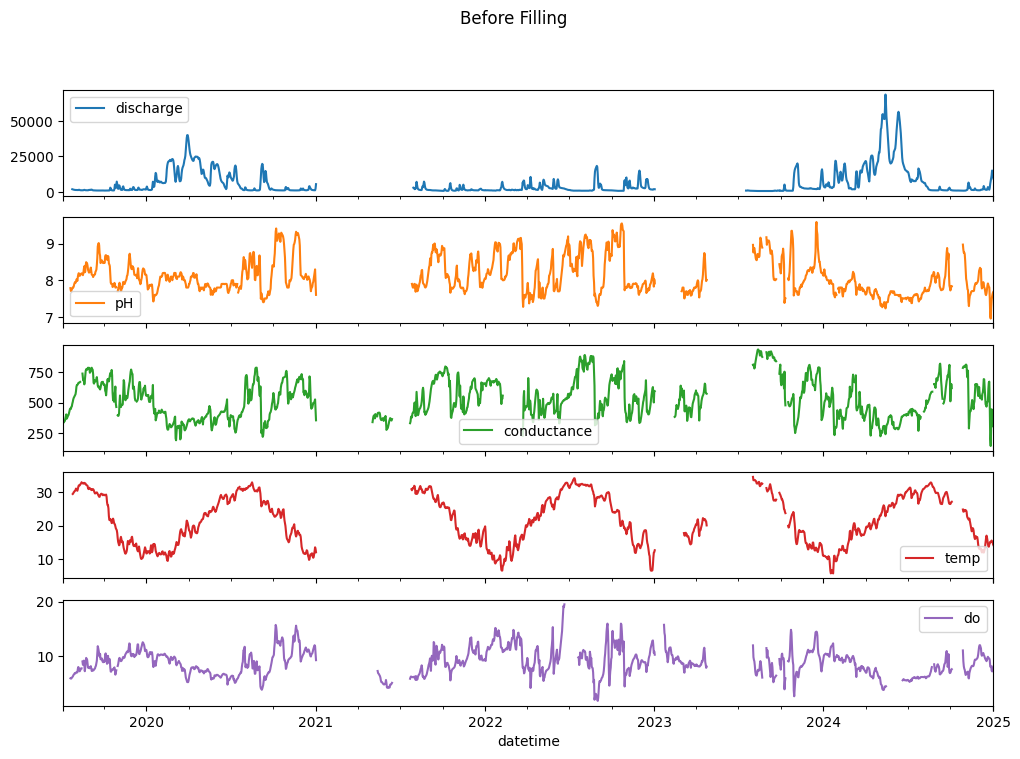

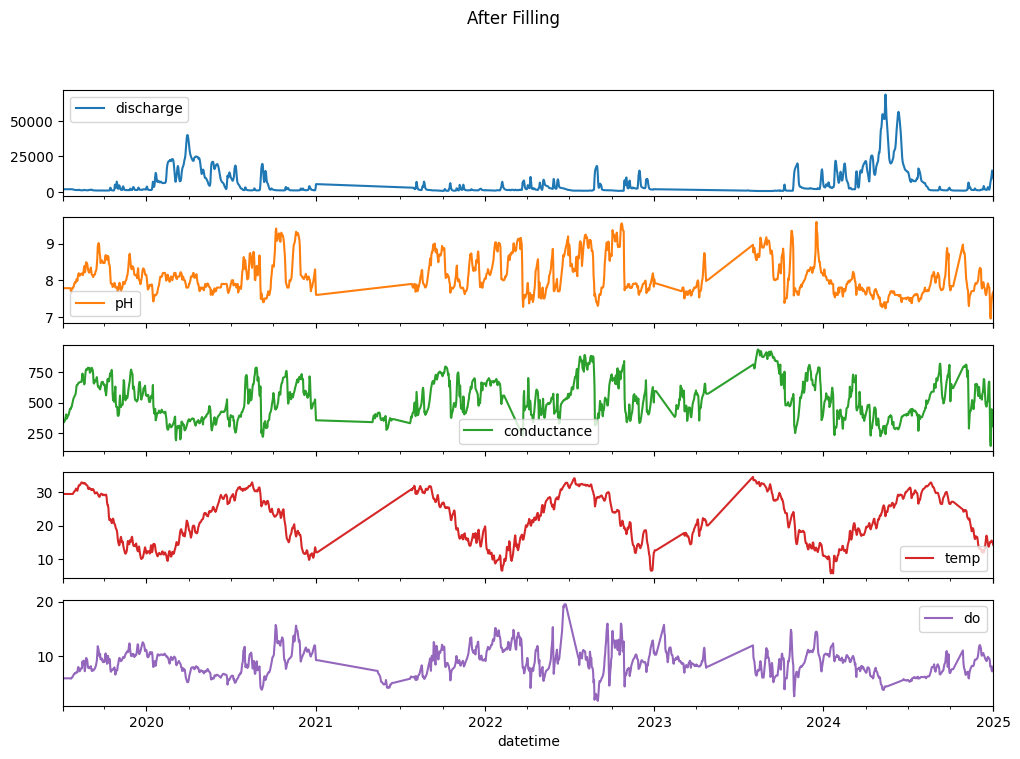

In [ ]:
df_resampled.plot(subplots=True, figsize=(12,8), title="Before Filling")
plt.show()

df_filled.plot(subplots=True, figsize=(12,8), title="After Filling")
plt.show()

# **05 |** Modelling

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_filled)

scaled_df = pd.DataFrame(scaled, index=df_filled.index, columns=df_filled.columns)

In [ ]:
scaled_df

,discharge,pH,conductance,temp,do
datetime,,,,,
2019-07-06 00:00:00+00:00,0.019411,0.314817,0.242244,0.823073,0.233797
2019-07-07 00:00:00+00:00,0.019411,0.314817,0.245291,0.823073,0.233797
2019-07-08 00:00:00+00:00,0.019411,0.314817,0.257120,0.823073,0.233797
2019-07-09 00:00:00+00:00,0.019411,0.314817,0.259465,0.823073,0.233797
2019-07-10 00:00:00+00:00,0.019411,0.314817,0.282511,0.823073,0.233797
...,...,...,...,...,...
2024-12-29 00:00:00+00:00,0.162367,0.189499,0.380439,0.340579,0.314454
2024-12-30 00:00:00+00:00,0.212809,0.227793,0.216556,0.328824,0.305839
2024-12-31 00:00:00+00:00,0.208966,0.253849,0.206245,0.327187,0.307137


## **04.02 |** LSTM

In [ ]:
def create_sequences(data, seq_len, horizon=30):
    X, y = [], []
    for i in range(len(data) - seq_len - horizon):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len:i+seq_len+horizon])  # 365 future values
    return np.array(X), np.array(y)

seq_len = 120
HORIZON = 30

X, y = create_sequences(scaled_df.values, seq_len=seq_len, horizon=HORIZON)

In [ ]:
n = len(X)

train_end = int(0.7 * n)
val_end = int(0.85 * n)

X_train = X[:train_end]
y_train = y[:train_end]

X_val = X[train_end:val_end]
y_val = y[train_end:val_end]

X_test = X[val_end:]
y_test = y[val_end:]

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.LSTM(128, return_sequences=True, input_shape=(seq_len, X.shape[2])),
    layers.Dropout(0.2),

    layers.LSTM(64),
    layers.Dropout(0.2),

    layers.RepeatVector(HORIZON),

    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),

    layers.TimeDistributed(layers.Dense(64, activation='relu')),
    layers.TimeDistributed(layers.Dense(X.shape[2]))
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.Huber(),
    metrics=['mae']
)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 120, 128)       │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 120, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_2 (RepeatVector)  │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 30, 64)         │         4,160 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 30, 5)          │           325 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 155,525 (607.52 KB)

 Trainable params: 155,525 (607.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                              patience=5,
                                              restore_best_weights=True)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    shuffle=False,
    verbose=1
)

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 16s 219ms/step - loss: 0.0284 - mae: 0.1837 - val_loss: 0.0197 - val_mae: 0.1571
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 205ms/step - loss: 0.0172 - mae: 0.1405 - val_loss: 0.0200 - val_mae: 0.1542
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 208ms/step - loss: 0.0145 - mae: 0.1283 - val_loss: 0.0236 - val_mae: 0.1594
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 173ms/step - loss: 0.0142 - mae: 0.1262 - val_loss: 0.0151 - val_mae: 0.1309
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 215ms/step - loss: 0.0124 - mae: 0.1176 - val_loss: 0.0150 - val_mae: 0.1320
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 214ms/step - loss: 0.0120 - mae: 0.1151 - val_loss: 0.0186 - val_mae: 0.1436
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 178ms/step - loss: 0.0115 - mae: 0.1129 - val_loss: 0.0133 - val_mae: 0.1251
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 180ms/step - loss: 0.0104 - mae: 0.1061 - val_loss: 0.0131 - val_mae: 0.1239
Epoch 9/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 199ms/step -

In [ ]:
preds_train = model.predict(X_train)

preds_train_2d = preds_train.reshape(-1, preds_train.shape[2])
y_train_2d = y_train.reshape(-1, y_train.shape[2])

preds_train_inv_2d = scaler.inverse_transform(preds_train_2d)
y_train_inv_2d = scaler.inverse_transform(y_train_2d)

preds_train_inv = preds_train_inv_2d.reshape(preds_train.shape)
y_train_inv = y_train_inv_2d.reshape(y_train.shape)

# reshape to 2D
preds_2d = preds.reshape(-1, preds.shape[2])
y_test_2d = y_test.reshape(-1, y_test.shape[2])

# inverse transform
preds_inv_2d = scaler.inverse_transform(preds_2d)
y_test_inv_2d = scaler.inverse_transform(y_test_2d)

# reshape back to 3D
preds_inv = preds_inv_2d.reshape(preds.shape)
y_test_inv = y_test_inv_2d.reshape(y_test.shape)

41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step


In [ ]:
preds_val = model.predict(X_val)

preds_val_2d = preds_val.reshape(-1, preds_val.shape[2])
y_val_2d = y_val.reshape(-1, y_val.shape[2])

preds_val_inv_2d = scaler.inverse_transform(preds_val_2d)
y_val_inv_2d = scaler.inverse_transform(y_val_2d)

preds_val_inv = preds_val_inv_2d.reshape(preds_val.shape)
y_val_inv = y_val_inv_2d.reshape(y_val.shape)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step


In [ ]:
scaled_df.columns

Index(['discharge', 'pH', 'conductance', 'temp', 'do'], dtype='object')

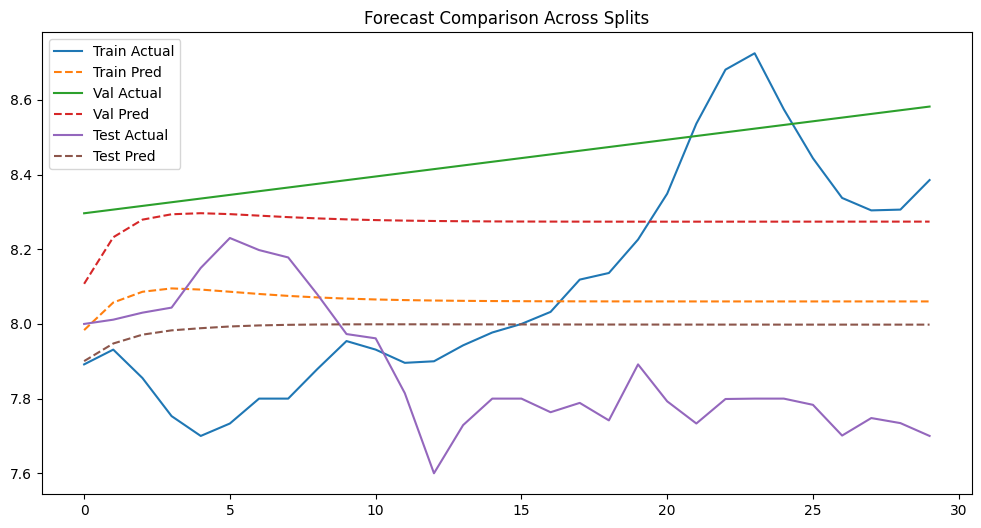

In [ ]:
sample = 0
feature = 1  # discharge

plt.figure(figsize=(12,6))

plt.plot(y_train_inv[sample, :, feature], label='Train Actual')
plt.plot(preds_train_inv[sample, :, feature], '--', label='Train Pred')

plt.plot(y_val_inv[sample, :, feature], label='Val Actual')
plt.plot(preds_val_inv[sample, :, feature], '--', label='Val Pred')

plt.plot(y_test_inv[sample, :, feature], label='Test Actual')
plt.plot(preds_inv[sample, :, feature], '--', label='Test Pred')

plt.legend()
plt.title("Forecast Comparison Across Splits")
plt.show()

In [ ]:
print("Pred mean:", preds.mean())
print("Target mean:", y_test.mean())

Pred mean: 0.36525837
Target mean: 0.36829171685477186
